# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 56    |  |
| :-------------|:-------------|
| Raoul Staas          | 6529003 |
| Fiene Castillo Gosker| 6152678 |
| Lars Mulder          | 6546862 |

| Planning Groep: 56     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12:00 |
| Mijlpaal 2: meetplan maken | 14:15|
| Mijlpaal 3: Eerste kalibratie meting gedaan| 14:45 |
| Mijlpaal 4: python code/ fitten van data |16:15|
| Mijlpaal 5: opdracht af |16:30|
| Mijlpaal 6: opruimen en laatste checks |17:15|
| Pauze 1| 12:30-13:45 |
| Pauze 2| 15:45-16:00 |

## *Opdracht 1*: Foto van alle schetsen.

![Alt](sensor_toepassingen.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor      | Toepassing  | Criteria | 
|:---|:---|:---|
|Thermistor   | thermostaat | kan graden meten tussen 10 en 40 graden |
|Thermistor   | thermostaat | op de graad nauwkeurig |
|Thermistor   | thermostaat | dat de sensor blijft werken bij 60 graden celsius|
|LDR          | lantaarnpaal: gaat aan als het buiten donker genoeg is (gaat aan onder de 20 lux) | kan lichtsterkte meten tussen 0 en 100 lux |
|LDR          | lantaarnpaal: gaat aan als het buiten donker genoeg is (gaat aan onder de 20 lux) | op 2 lux nauwkeurig |
|LDR          | lantaarnpaal: gaat aan als het buiten donker genoeg is (gaat aan onder de 20 lux) | moet tegen zonneschade kunnen voor 3 jaar |
|force sensor | als een deur te lang openstaat (geen druk voelt) gaat die vanzelf dicht | kan verschil meten tussen 0 en 20 N |
|force sensor | als een deur te lang openstaat (geen druk voelt) gaat die vanzelf dicht | op 1 N nauwkeurig |
|force sensor | als een deur te lang openstaat (geen druk voelt) gaat die vanzelf dicht | sensor blijft heel bij 100N |


Groep 56 heeft gekozen voor sensor thermistor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](meetopstelling_schets.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? \
We veranderen de temperatuur
2. Over welk bereik ga je deze variabelen veranderen?  \
we veranderen de temperatuur van 4 graden (buiten) tot 40 graden (naast de verwarming) 
3. Wat ga je allemaal meten? \
de temperatuur en de correspnderende waarde van de arduino bij deze temperatuur 
4. Hoeveel metingen ga je doen? \
10 metingen tussen de 4 en 40 graden met een interval van 4 graden 
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen? \
ja, uit deze metingen kan bepaald worden of aan de vooraf vastgestelde criteria voldaan is


## *Meetprocedure*

1) bouw de meetopstelling zoals weergegeven in opdracht 3 
2) hou de thermometer 1 cm naast de thermistor
3) houd andere variabelen constant: wind, zonlicht
4) doe 10 metingen tussen de 4 en 40 graden met een interval van 4 graden
5) kijk of de thermistor werkt bij 60 graden water

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
op de foto is een schakeling te zien met een thermistor aangesloten op een Arduino en een thermometer
 ![Alt](meetopstelling.jpeg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 
# data
arduino = np.array ([336,340,350,415,443, 471, 555,576, 665])
therm = np.array ([4.7,7.5,8.0,14.8,19.5, 20.5, 25,28.7, 43])

u_therm = 0.3
u_arduino = 1

def fitfunc(x,a,b):
    return a*x+b

val, cov = curve_fit(fitfunc, therm, arduino, p0=[0.1,300])
a_fit = val[0]
b_fit = val[1]

<function matplotlib.pyplot.show(close=None, block=None)>

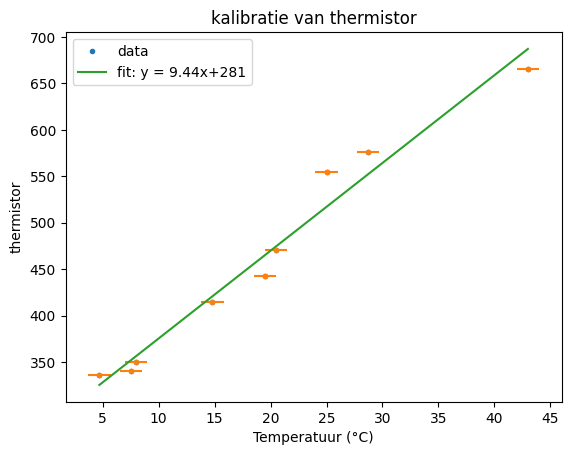

In [2]:
x_test = np.linspace(min(therm), max(therm), 1000)
y_test = fitfunc(x_test, a_fit, b_fit)

plt.figure
plt.title("kalibratie van thermistor")
plt.plot(therm,arduino,".", label= "data")
plt.errorbar(therm,arduino, u_therm, u_arduino,".")
plt.plot(x_test,y_test, label="fit: y = {:.2f}x+{:.0f}".format(a_fit,b_fit))
plt.legend()
plt.ylabel("thermistor")
plt.xlabel("Temperatuur (°C)")
plt.show


## *Opdracht 7*: Iteratie nodig?

ja er zou nog gemeten kunnen worden tussen 30 en 40 graden, maar er is geen plek waar we deze meting kunnen uitvoeren.

## *Opdracht 8*: Conclusie, leerdoel
Uit de data blijkt dat de sensor temperaturen kan meten tussen de 10 en 40 graden, maar niet op 1 graad nauwkeurig. Dit komt doordat de thermometer niet acuraat was en veel schommelingen weergaf in de temperatuur, waardoor we niet goed de temperatuurwaarde aan de arduino waarde konden koppelen, die overigens wel heel acurate waardes weergaf. Als er een betere thermometer gebruikt wordt kan de sensor hoogst waarschijnlijk gebruikt worden voor een thermostaat, maar omdat wij die niet hadden voldoet de sensor nu nog niet aan onze criteria 

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

 ![Alt](meetopstelling.jpeg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

| Sensor      | Toepassing  | Criteria | 
|:---|:---|:---|
|Thermistor   | thermostaat | kan graden meten tussen 10 en 40 graden |
|Thermistor   | thermostaat | op de graad nauwkeurig |
|Thermistor   | thermostaat | dat de sensor blijft werken bij 60 graden celsius|

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

## conclusie
Uit de data blijkt dat de sensor temperaturen meten tussen de 10 en 40 graden, maar niet op 1 graad nauwkeurig. Er was geen mogelijkheid om de temperatuur tot 60 graden te laten komen dus ook dit criterium is nog niet bewezen. Dit komt onder andere doordat de thermometer niet snel en accuraat temperatuurverschillen kon meten. De Arduino kon dit wel snel en nauwkeurig dus met een betere thermometer voldoet de sensor waarschijnlijk wel aan onze criteria.

<function matplotlib.pyplot.show(close=None, block=None)>

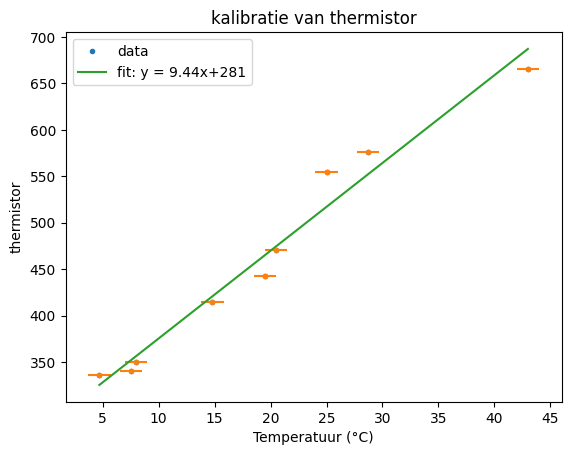

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 
# data
arduino = np.array ([336,340,350,415,443, 471, 555,576, 665])
therm = np.array ([4.7,7.5,8.0,14.8,19.5, 20.5, 25,28.7, 43])

u_therm = 0.3
u_arduino = 1

def fitfunc(x,a,b):
    return a*x+b

val, cov = curve_fit(fitfunc, therm, arduino, p0=[0.1,300])
a_fit = val[0]
b_fit = val[1]

x_test = np.linspace(min(therm), max(therm), 1000)
y_test = fitfunc(x_test, a_fit, b_fit)

plt.figure
plt.title("kalibratie van thermistor")
plt.plot(therm,arduino,".", label= "data")
plt.errorbar(therm,arduino, u_therm, u_arduino,".")
plt.plot(x_test,y_test, label="fit: y = {:.2f}x+{:.0f}".format(a_fit,b_fit))
plt.legend()
plt.ylabel("thermistor")
plt.xlabel("Temperatuur (°C)")
plt.show


 ![Alt](meetopstelling.jpeg "meetopstelling student")